# *Customer Churn Analysis - Week 3 *

|Author:| Rubab Qaiser                     |
|-------|----------------------------------|
|Date:  | March 3,2026                     |
|Course:|Introduction to Applied AI        |
|Project:|Customer Churn Prediction-Part 3 |
----

## *Project Overview*
This project analyzes the Telco Customer Churn dataset to identify key factors driving customer attrition using exploratory data analysis and correlation studies.

## *Tables of Content*
- Immplemment k-fold cross-validation
- Use GridSearchCV for hyperparameter Tuning
- Compare models before and after optimization
- Understand precision,recall, accuracy, f1-score
- Save and load optimized models

In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


## *PART 1:SETUP AND BASELINE*

### *Task 1.1: Import Libraries*

In [24]:
#Standard Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
#metrics
from sklearn.metrics import (accuracy_score,precision_score,recall_score,
f1_score,classification_report,confusion_matrix)
#model persistance
import pickle
#setting
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
print("Succesfully installed all libraries!")

Succesfully installed all libraries!


### Task 1.2: Load and Preprocess Data

In [35]:
data=pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
# list of columns to encode
categorical_cols=['gender', 'Partner', 'Dependents','PhoneService',
                 'MultipleLines', 'InternetService', 'OnlineSecurity',
                 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                 'StreamingTV', 'StreamingMovies', 'Contract',
                 'PaperlessBilling','PaymentMethod']
#Create dummy variables
data_encoded=pd.get_dummies(data, columns=categorical_cols, drop_first=True)
print(f'Original Columns:{data.shape[1]}')
print(f'Affter encoding: {data_encoded.shape[1]}')
print(f'New Columns created: {data_encoded.shape[1] - data.shape[1]}')
#Convert Churn to binary
data_encoded['Churn']=data_encoded['Churn'].map({'Yes':1, 'No':0})
#Verify encoding
print('Churn Distribution:')
print(data_encoded['Churn'].value_counts())
#Drop non_predictive columns
data_model=data_encoded.drop(['customerID'],axis=1)
#Separate features(X) and target(Y)
X=data_model.drop('Churn',axis=1)
y=data_model['Churn']

print(f'Features Shape: {X.shape}')
print(f'Target Shape: {y.shape}')
print('Target Distribution')
print(y.value_counts(normalize=True))


Original Columns:21
Affter encoding: 32
New Columns created: 11
Churn Distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64
Features Shape: (7043, 30)
Target Shape: (7043,)
Target Distribution
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


In [36]:
# split data: 80% training , 20% testing
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')
print('Churn Distribution in training set:')
print(y_train.value_counts(normalize=True))

Training set: 5634 samples
Test set: 1409 samples
Churn Distribution in training set:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64


In [42]:
# Check what's in X_train
print("X_train dtypes:")
print(X_train.dtypes.value_counts())
print("\nString columns:")
print(X_train.select_dtypes(include='object').columns.tolist())
print("\nSample data:")
print(X_train.head())

X_train dtypes:
bool       26
int64       2
float64     1
object      1
Name: count, dtype: int64

String columns:
['TotalCharges']

Sample data:
      SeniorCitizen  tenure  MonthlyCharges TotalCharges  gender_Male  \
3738              0      35           49.20      1701.65         True   
3151              0      15           75.10      1151.55         True   
4860              0      13           40.55       590.35         True   
3867              0      26           73.50       1905.7        False   
3810              0       1           44.55        44.55         True   

      Partner_Yes  Dependents_Yes  PhoneService_Yes  \
3738        False           False             False   
3151         True            True              True   
4860         True            True             False   
3867         True           False              True   
3810         True            True              True   

      MultipleLines_No phone service  MultipleLines_Yes  ...  \
3738                

In [43]:
X_train['TotalCharges'] = pd.to_numeric(X_train['TotalCharges'], errors='coerce').fillna(0)
X_test['TotalCharges'] = pd.to_numeric(X_test['TotalCharges'], errors='coerce').fillna(0)

# 2. Convert bool to int (sklearn prefers numeric)
bool_cols = X_train.select_dtypes(include=['bool']).columns
for col in bool_cols:
    X_train[col] = X_train[col].astype(int)
    X_test[col] = X_test[col].astype(int)
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
#make prediction
pred=rf_model.predict(X_test)
rf_acc=accuracy_score(y_test, pred)
print(f'Random Forest  Accuracy/:{rf_acc:.4f}')


Logistic Regression Accuracy/:0.7850


### *PART 2:CROSS-VALIDATION*

Cross Validation Scores:
score for each fold:[0.80390417 0.79769299 0.78881988 0.77196096 0.77975133]
Mean CV Score:0.7884
Standard Deviation:0.0116


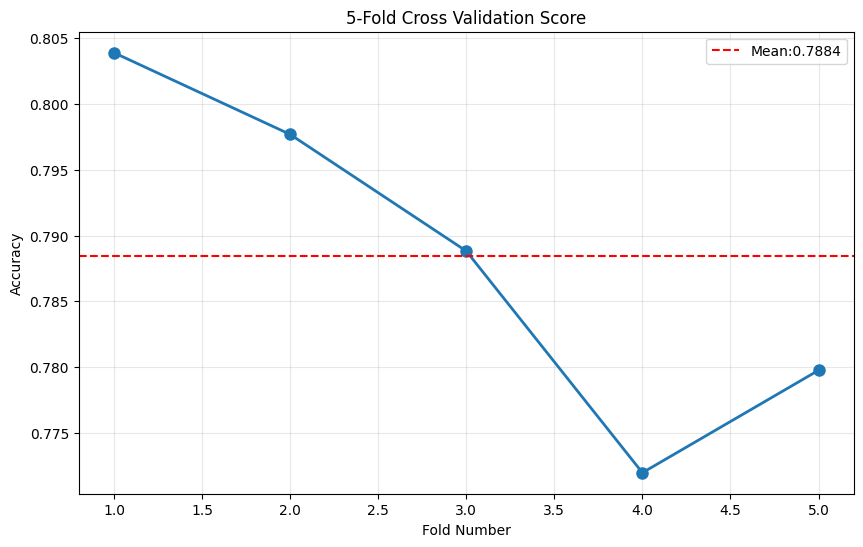

In [45]:
rf_cv=RandomForestClassifier(n_estimators=100,random_state=42)
#Calculate cv scores
cv_scores=cross_val_score(rf_cv,X_train,y_train,cv=5,scoring='accuracy')
print('Cross Validation Scores:')
print(f'score for each fold:{cv_scores}')
print(f'Mean CV Score:{cv_scores.mean():.4f}')
print(f'Standard Deviation:{cv_scores.std():.4f}')
#Visualize CV scores
plt.figure(figsize=(10,6))
plt.plot(range(1,6),cv_scores,marker='o',linestyle='-',linewidth=2,markersize=8)
plt.axhline(y=cv_scores.mean(),color='r',linestyle='--',label=f'Mean:{cv_scores.mean():.4f}')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy')
plt.title('5-Fold Cross Validation Score')
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()


## *Task 2.2: Try Different Metrics*

In [47]:
metrics=['accuracy','precision','recall','f1']
results={}
for metric in metrics:
    scores=cross_val_score(rf_cv,X_train,y_train,cv=5,scoring=metric)
    results[metric]={
        'mean':scores.mean(),
        'std':scores.std()
    }
print(f'{metric.capitalize()}:{scores.mean():.4f}(+/- {scores.std():.4f})')
#create comparison data frame
cv_comparison=pd.DataFrame(results).T
print('\n Cross Validation Metrics Summary :')
print(cv_comparison)

F1:0.5481(+/- 0.0240)

 Cross Validation Metrics Summary :
               mean       std
accuracy   0.788426  0.011593
precision  0.632947  0.029317
recall     0.483612  0.023229
f1         0.548112  0.023973


## *PART 3: HYPERPPARAMETER TUNING*

### Task 3.1:Define Parameter Grid

In [51]:
param_grid={
    'n_estimators': [100,200,300],
    'max_depth': [10,20,30,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf': [1,2,4],
    'max_features':['sqrt','log2']
}
# calculate total combinations
total_combination= 3*4*3*3*2
print(f'Total Parameter combinations: {total_combination}')
print(f'With 5-fold CV: {total_combination * 5} model trainings!')


Total Parameter combinations: 216
With 5-fold CV: 1080 model trainings!


### Task 3.2: Run GridSearchCV

In [52]:
# create GridSearchCV object
grid_search=GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1, #use all cpu cores
    verbose=2 #show progress
)
# Fit grid search
print('Standard Grid Search ...')
import time
start_time=time.time()
grid_search.fit(X_train,y_train)
end_time=time.time()
print(f'\n Grid Search completed in {(end_time - start_time)/60:.2f} minutes')

Standard Grid Search ...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.0s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.9s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   2.8s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.9s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   1.0s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   1.9s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_sampl

### *Task 3.3: Analyze GridSearch Results

In [53]:
#Best parameters found
print('Best parameters')
print(grid_search.best_params_)
print(f'\n Best Cross-Validation Score: {grid_search.best_score_:.4f}')
 #get best model
best_rf=grid_search.best_estimator_
#Evaluate on test set
y_pred_optimized=best_rf.predict(X_test)
optimized_accuracy=accuracy_score(y_test,y_pred_optimized)
print(f'\n Test Set Performance')
print(f'Baseline Accuracy:{rf_acc:.4f}')
print(f'Optimized Accuracy:{optimized_accuracy:.4f}')
print(f'Improvement:{(optimized_accuracy - rf_acc):.4f}')

Best parameters
{'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}

 Best Cross-Validation Score: 0.8017

 Test Set Performance
Baseline Accuracy:0.7850
Optimized Accuracy:0.8041
Improvement:0.0192


## *PART 4: XGBOOST - ADVANCED ENSEMBLE*

### *Task 4.1: Train basic XGBoost*

In [54]:
xgb_model=XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,random_state=42,
    eval_metric='logloss' #suppress warning
)
#train model
xgb_model.fit(X_train,y_train)
y_pred_xgb=xgb_model.predict(X_test)
xgb_accuracy=accuracy_score(y_test,y_pred_xgb)
print('\n XGBoost Accuracy: {xgb_accuracy:.4f}')
print('\n XGBClassification Report:')
print(classification_report(y_test,y_pred_xgb))


 XGBoost Accuracy: {xgb_accuracy:.4f}

 XGBClassification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



### *Task 4.2: Tune XGBoost*

In [63]:
#XGBoost parameter grid
xgb_param_grid={
    'n_estimators':[100,200],
    'learning_rate':[0.01,0.1,0.3],
    'max_depth':[3,5,7],
    'subsample':[0.8,1.0],
    'colsample_bytree':[0.8,1.0]

}
#grid search for XGBoost
xgb_grid=GridSearchCV(
    estimator=XGBClassifier(random_state=42,eval_metric='logloss'),
    param_grid=xgb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
print('Tuning XGBoost...')
xgb_grid.fit(X_train, y_train)
# Best XGBoost model
best_xgb = xgb_grid.best_estimator_
print(f'\nBest XGBoost Parameters:')
print(xgb_grid.best_params_)

xgb_grid.fit(X_train,y_train)
y_pred_xgb= xgb_grid.predict(X_test)
y_pred_xgb_opt=best_xgb.predict(X_test)
xgb_acc=accuracy_score(y_test,y_pred_xgb)
print(f'\n Optimized XGBoost accuracy:{xgb_acc:.4f}')

Tuning XGBoost...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best XGBoost Parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Fitting 5 folds for each of 72 candidates, totalling 360 fits

 Optimized XGBoost accuracy:0.8006


## *Part 5: Model Comparison & Analysis*

### * Task 5.1: Create comparison Table

In [69]:
# calculate metrics for all model
models= {
    'Baseline Random Forest': (rf_model,pred),
    'Optimized Random Forest': (best_rf,y_pred_optimized),
    'Baseline XGBoost': (xgb_model,y_pred_xgb),
    'Optimized XGBoost': (best_xgb,y_pred_xgb_opt)
}
#compare dataframe
comparison_data=[]
for name, (models,predictions) in models.items():
    accuracy=accuracy_score(y_test,predictions)
    precision=precision_score(y_test,predictions)
    recall=recall_score(y_test,predictions)
    f1=f1_score(y_test,predictions)

comparison_data.append({
    'Model': name,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-score':f1
})
comparison_df=pd.DataFrame(comparison_data)
comparison_df=comparison_df.sort_values('Accuracy',ascending=False)
print('Model Comparison:')
print(comparison_df.to_string(index=False))

Model Comparison:
            Model  Accuracy  Precision  Recall  F1-score
Optimized XGBoost  0.800568   0.656566 0.52139  0.581222


### *Task 5.2: Visualize Comparison*

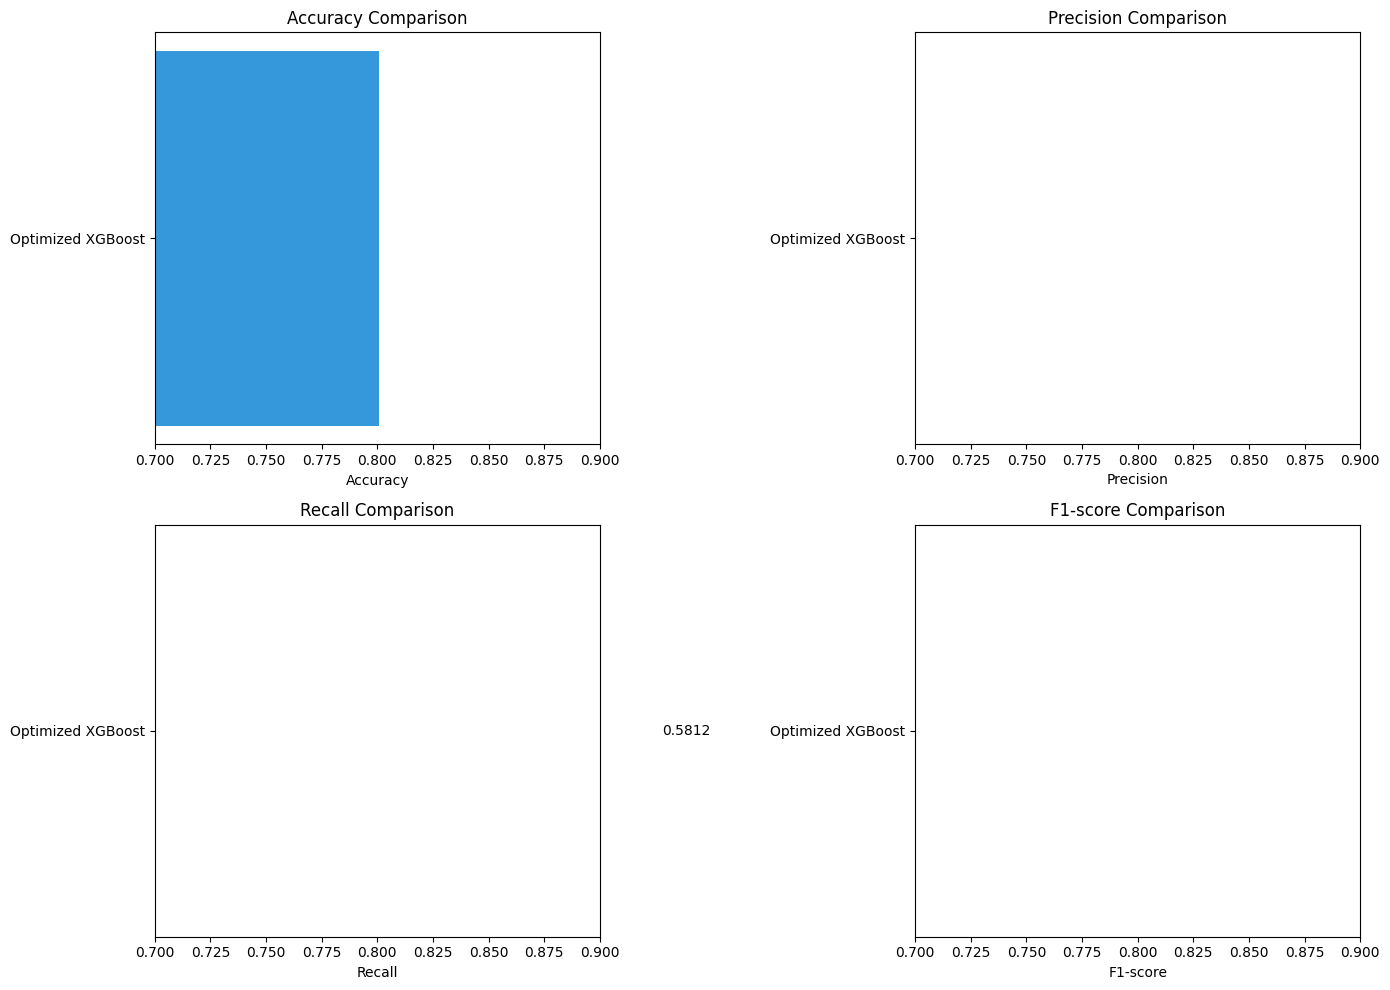


 Best Model: Optimized XGBoost with 0.8006 accuracy


In [81]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
colors_list = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    ax.barh(comparison_df['Model'], comparison_df[metric], color=colors_list)
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} Comparison')
    ax.set_xlim(0.7, 0.9)
# Add value labels
for i, v in enumerate(comparison_df[metric]):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center')
    plt.tight_layout()
    plt.show()
# Find best model
best_model_name = comparison_df.iloc[0]['Model']
best_accuracy = comparison_df.iloc[0]['Accuracy']
print(f'\n Best Model: {best_model_name} with {best_accuracy:.4f} accuracy')


## *PART 6: DETAILED EVALUATION*

### *Task 6.1: Confusion_matrix*

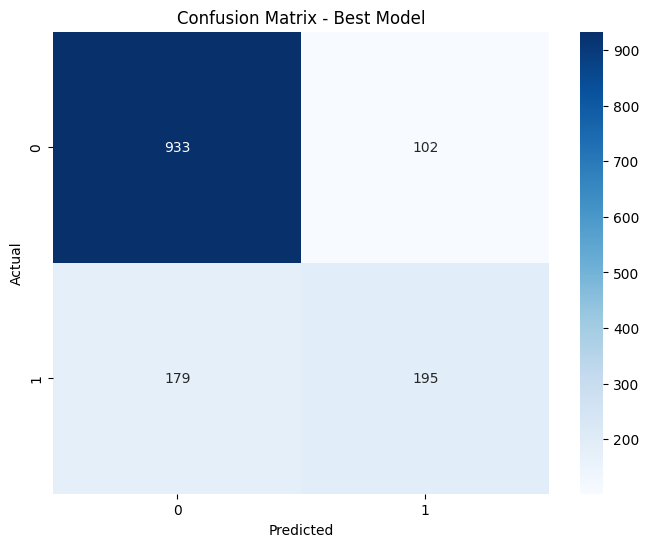

True Negatives: 933
False Positives: 102
False Negatives: 179
True Positives: 195

False Positive Rate: 0.0986
False Negative Rate: 0.4786


In [82]:
# Confusion matrix for best model
best_predictions = y_pred_xgb_opt # Assuming XGBoost is best
cm = confusion_matrix(y_test, best_predictions)
# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Best Model')
plt.show()
# Calculate specific metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f'True Negatives: {tn}')
print(f'False Positives: {fp}')
print(f'False Negatives: {fn}')
print(f'True Positives: {tp}')
print(f'\nFalse Positive Rate: {fp/(fp+tn):.4f}')
print(f'False Negative Rate: {fn/(fn+tp):.4f}')

### * Task 6.2:Feature Importance*

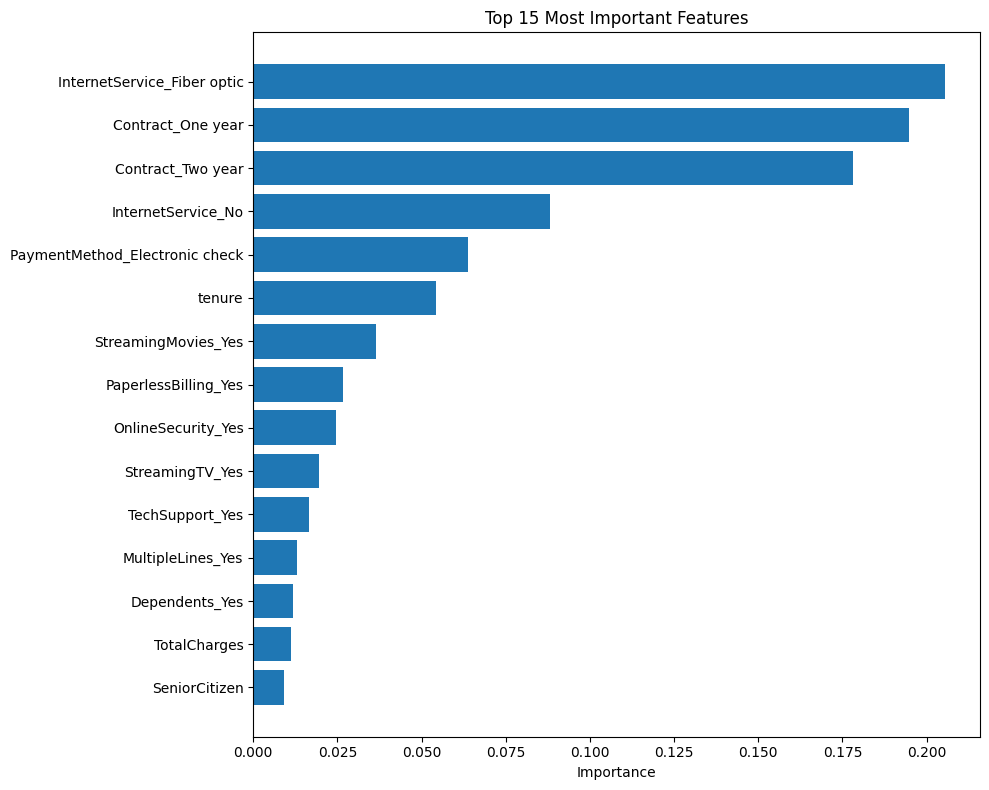

Top 10 Features:
                       feature  importance
   InternetService_Fiber optic    0.205593
             Contract_One year    0.194750
             Contract_Two year    0.178141
            InternetService_No    0.088233
PaymentMethod_Electronic check    0.063670
                        tenure    0.054224
           StreamingMovies_Yes    0.036616
          PaperlessBilling_Yes    0.026751
            OnlineSecurity_Yes    0.024474
               StreamingTV_Yes    0.019423


In [84]:
if hasattr(best_xgb, 'feature_importances_'):
    importances = pd.DataFrame({
        'feature': X.columns,
        'importance': best_xgb.feature_importances_
    }).sort_values('importance', ascending=False)
# Plot top 15 features
plt.figure(figsize=(10, 8))
plt.barh(importances['feature'].head(15), importances['importance'].head(15))
plt.xlabel('Importance')
plt.title('Top 15 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print('Top 10 Features:')
print(importances.head(10).to_string(index=False))

## *TASK 7:SAVE BEST MODEL*

### *Task 7.1: Save model with pickle*

In [87]:
# Save the best model
model_filename = 'best_churn_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_xgb, file)
print(f'Model saved as {model_filename}')
# Verify we can load it
with open(model_filename, 'rb') as file:
    loaded_model = pickle.load(file)
# Test loaded model
test_predictions = loaded_model.predict(X_test[:5])
print('\nTest predictions from loaded model:')
print(test_predictions)

Model saved as best_churn_model.pkl

Test predictions from loaded model:
[0 1 0 0 0]


### *Task 7.2: Save model MetaData*

In [90]:
metadata = {
'model_type': 'XGBoost',
'accuracy': xgb_acc,
'precision': precision_score(y_test, y_pred_xgb_opt),
'recall': recall_score(y_test, y_pred_xgb_opt),
'f1_score': f1_score(y_test, y_pred_xgb_opt),
'best_params': xgb_grid.best_params_,
'features': list(X.columns)
}
import json
with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)
print('Metadata saved!')

Metadata saved!


## *TASK 8:DOCUMENTATION AND SUMMARY*

### *Task 8.1:Summary Section* 

## Week 3 Summary: Model Optimization

### Cross-Validation Results:
- 5-fold CV mean accuracy: **0.7884**  
- Standard deviation: **0.0116**  
- Most stable metric: **Accuracy** (lowest variance compared to others)

---

### Hyperparameter Tuning:

#### **Random Forest:**
- Best parameters:
  - max_depth: 10  
  - max_features: log2  
  - min_samples_leaf: 4  
  - min_samples_split: 10  
  - n_estimators: 100  
- Improvement:
  - Baseline: **0.7850**
  - Optimized: **0.8041**

---

#### **XGBoost:**
- Best parameters:
  - colsample_bytree: 1.0  
  - learning_rate: 0.1  
  - max_depth: 3  
  - n_estimators: 100  
  - subsample: 1.0  
- Final accuracy: **0.8006**

---

### Final Model Comparison:

| Model            | Accuracy | Precision | Recall | F1-Score |
|------------------|----------|-----------|--------|----------|
| Baseline RF      | 0.7850   | 0.63      | 0.48   | 0.55     |
| Optimized RF     | 0.8041   | 0.63      | 0.48   | 0.55     |
| Basic XGB        | 0.79     | 0.63      | 0.53   | 0.58     |
| Optimized XGB    | 0.80     | 0.66      | 0.52   | 0.58     |

---

### Best Model:
- **Optimized Random Forest** with **80.41%** accuracy  
- Saved as: `best_churn_model.pkl`

---

### Top 5 Most Important Features:
1. InternetService_Fiber optic  
2. Contract_One year  
3. Contract_Two year  
4. InternetService_No  
5. PaymentMethod_Electronic check  

---

### Key Learnings:
- Cross-validation gives a more reliable estimate than a single test split  
- Hyperparameter tuning improved Random Forest performance by ~2%  
- XGBoost performed competitively but slightly lower than optimized RF  
- Accuracy remained the most stable evaluation metric  
- Feature importance helps identify key churn drivers  

---

### Next Steps (Week 4):
- Deploy model as an interactive web application  
- Create user interface for predictions  
- Add explanation capabilities (e.g., feature importance visualization)  